In [1]:
import pandas as pd
import math
import numpy as np
import sympy as sp
import scipy.stats as sts
import matplotlib.pyplot as plt
import statistics as st

ЧАСТЬ I

1. Смоделировать выборку из п независимых наблюдений над случайной величиной X, 
имеющей нормальный закон распределения.

In [2]:
n = 14
a = -0.5
sigma = 2
gamma = 0.95
M = 1800
K = 170

In [34]:
sample = np.random.normal(a, sigma, n)
mean = st.mean(sample)
print(sample)
print(mean)

[-1.93130132  0.6434766  -6.12722115  1.03571338 -3.33127267 -1.97726993
 -2.26062674 -0.34437886 -1.39532297 -1.92040774 -2.14363896 -1.81887058
 -2.08829967  1.68878583]
-1.5693310552748505


1.1. С надежностью gamma найти интервальную оценку (доверительный интервал) для 
математического ожидания случайной величины X, предполагая, что дисперсия 
случайной величины X известна (см. УКАЗАНИЕ).

In [35]:
t = (gamma+1.0)/2.0
t_gamma=sts.norm.ppf(t)


delta = t_gamma * sigma/math.sqrt(n)
left_0 = mean - delta
right_0 = mean + delta

print(f"доверительный интервал: {left_0} - {right_0}")

доверительный интервал: -2.6169758724984478 - -0.5216862380512532


In [36]:
interval_0 = sts.norm.interval(gamma, mean, sigma/math.sqrt(n))
print("доверительный интервал: ", interval_0)

доверительный интервал:  (-2.6169758724984478, -0.5216862380512532)


1.2. С надежностью gamma найти интервальную оценку (доверительный интервал) для 
математического ожидания случайной величины X, предполагая, что дисперсия 
случайной величины X неизвестна (см. УКАЗАНИЕ).

In [37]:
S = np.sqrt(1/(n-1)*np.sum((sample-sample.mean())**2))
t_2_gamma = sts.t.ppf(t, df = n-1)
delta = (t_2_gamma*S)/np.sqrt(n)
left_1 = mean - delta
right_1 = mean + delta
print(f"доверительный интервал: {left_1}, {right_1}")

доверительный интервал: -2.693349144125556, -0.4453129664241451


In [38]:
interval_1 = sts.t.interval(gamma, n-1, mean, S/math.sqrt(n))
print("доверительный интервал:", interval_1)

доверительный интервал: (-2.693349144125556, -0.4453129664241451)


1.3. С надежностью gamma найти интервальную оценку (доверительный интервал) для 
дисперсии случайной величины X.

In [39]:
S2 = 1/(n-1)*np.sum((sample - sample.mean())**2)
print(np.var(sample, ddof = 1))
print(S2)
q1 = (1-gamma)/2
q2 = (1+gamma)/2
x_1 = sts.chi2.ppf(q1, n-1)
x_2 = sts.chi2.ppf(q2, n-1)
print(x_1, x_2)
chi2_lower, chi2_upper = sts.chi2.interval(gamma, n - 1)
print(chi2_lower, chi2_upper)
leftq = (n-1)*S2/x_2
rightq = (n-1)*S2/x_1
print(f"доверительный интервал дисперсии: {leftq} - {rightq}")
variance_interval = ((n -1) * S**2 / chi2_upper, (n - 1) * S**2 / chi2_lower)
print(variance_interval)

3.789822772113377
3.789822772113377
5.008750511810331 24.735604884931547
5.008750511810331 24.735604884931547
доверительный интервал дисперсии: 1.9917724376122625 - 9.836324632521354
(1.9917724376122623, 9.836324632521352)


2. Построить зависимость длины доверительного интервала от надежности при 
неизменном объеме выборки для случаев интервального оценивания математического 
ожидания и дисперсии.

In [40]:
# Создаём список уровней доверия
gamma_list = np.linspace(0.95, 0.999, 40)
gamma_list

array([0.95      , 0.95125641, 0.95251282, 0.95376923, 0.95502564,
       0.95628205, 0.95753846, 0.95879487, 0.96005128, 0.96130769,
       0.9625641 , 0.96382051, 0.96507692, 0.96633333, 0.96758974,
       0.96884615, 0.97010256, 0.97135897, 0.97261538, 0.97387179,
       0.97512821, 0.97638462, 0.97764103, 0.97889744, 0.98015385,
       0.98141026, 0.98266667, 0.98392308, 0.98517949, 0.9864359 ,
       0.98769231, 0.98894872, 0.99020513, 0.99146154, 0.99271795,
       0.99397436, 0.99523077, 0.99648718, 0.99774359, 0.999     ])

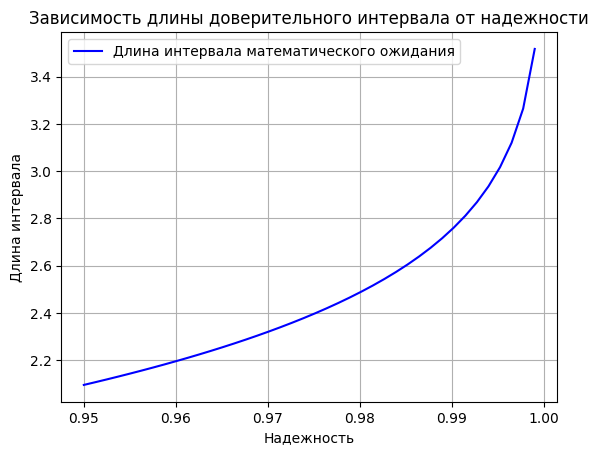

In [41]:
# Список для хранения длин интервалов для математического ожидания
x_mean_list = []

for g in gamma_list:
    
    mean_interval = sts.norm.interval(g, loc=sample.mean(), scale=sigma / np.sqrt(n))
    
    x_mean_list.append(mean_interval[1] - mean_interval[0])


plt.plot(gamma_list, x_mean_list, label="Длина интервала математического ожидания", color = "blue")
plt.xlabel("Надежность")
plt.ylabel("Длина интервала")
plt.legend()
plt.grid()
plt.title("Зависимость длины доверительного интервала от надежности")
plt.show()

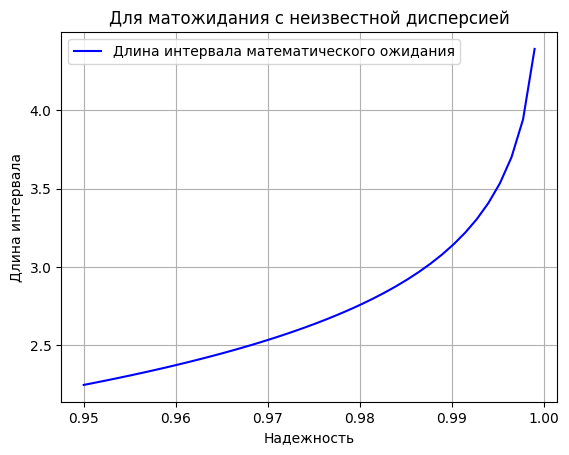

In [42]:
x_mean_list_2 = []


s = np.sqrt(np.var(sample, ddof = 1))
for g in gamma_list:
    
    # Вычисляем интервальную оценку для математического ожидания
    mean_interval = sts.t.interval(g, n-1, sample.mean(), scale= s/np.sqrt(n))
    
    # Вычисляем длину интервалов и добавляем их в списки
    x_mean_list_2.append(mean_interval[1] - mean_interval[0])


plt.plot(gamma_list, x_mean_list_2, label="Длина интервала математического ожидания", color = "blue")
plt.xlabel("Надежность")
plt.ylabel("Длина интервала")
plt.legend()
plt.title("Для матожидания с неизвестной дисперсией")
plt.grid()
plt.show()

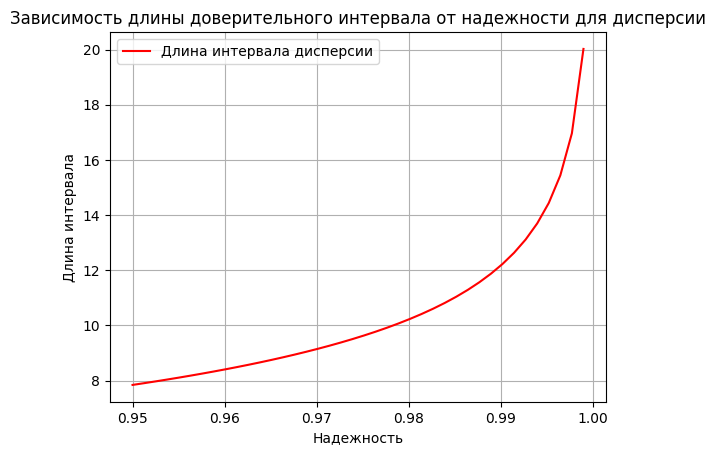

In [43]:
x_v_list = []

for g in gamma_list:

    chi2_lower, chi2_upper = sts.chi2.interval(g, n - 1)
    variance_interval = ((n -1) * S**2 / chi2_upper, (n - 1) * S**2 / chi2_lower)
    
    
    x_v_list.append(variance_interval[1] - variance_interval[0])

plt.plot(gamma_list, x_v_list, label="Длина интервала дисперсии", color = "red")
plt.xlabel("Надежность")
plt.ylabel("Длина интервала")
plt.legend()
plt.title("Зависимость длины доверительного интервала от надежности для дисперсии")
plt.grid()
plt.show()

3. Построить зависимость длины доверительного интервала от объема выборки при 
неизменной надежности для случаев интервального оценивания математического 
ожидания и дисперсии.

In [44]:
m_list = np.arange(10, 1000, 5)
m_list

array([ 10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,
        75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125, 130, 135,
       140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200,
       205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265,
       270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330,
       335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395,
       400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460,
       465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525,
       530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590,
       595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655,
       660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720,
       725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785,
       790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840, 845, 850,
       855, 860, 865, 870, 875, 880, 885, 890, 895, 900, 905, 91

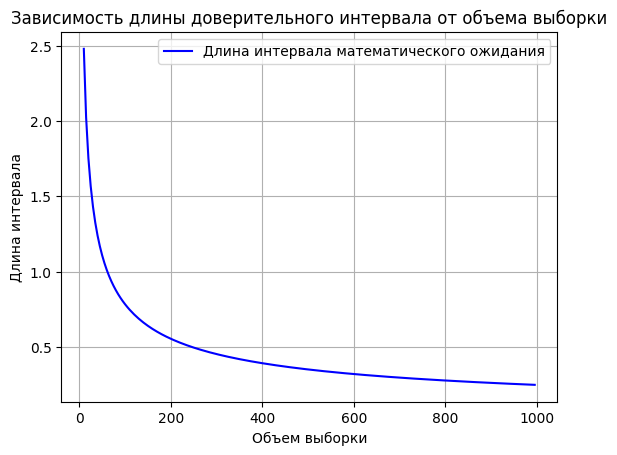

In [48]:
x_mean_list_3 = []

for m in m_list:
    sample_item = np.random.normal(a, sigma, m)

    # Вычисляем интервальную оценку для математического ожидания
    mean_interval = sts.norm.interval(gamma, loc=sample_item.mean(), scale=sigma / np.sqrt(m))
    
    x_mean_list_3.append(mean_interval[1] - mean_interval[0])


plt.plot(m_list, x_mean_list_3, label="Длина интервала математического ожидания", color = "blue")
plt.xlabel("Объем выборки")
plt.ylabel("Длина интервала")
plt.legend()
plt.grid()
plt.title("Зависимость длины доверительного интервала от объема выборки")
plt.show()

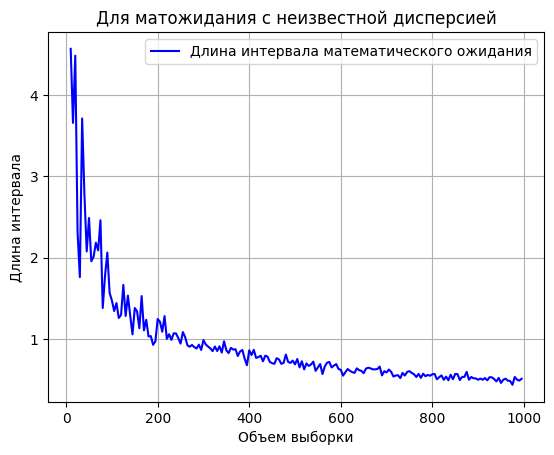

In [47]:
x_mean_list_4 = []


for m in m_list:
    sample_item = np.random.normal(a, sigma, m)
    s =np.var(sample_item, ddof = 1)
    
    # Вычисляем интервальную оценку для математического ожидания
    mean_interval = sts.t.interval(gamma, m, loc=sample_item.mean(), scale= s/np.sqrt(m) )

    x_mean_list_4.append(mean_interval[1] - mean_interval[0])


plt.plot(m_list, x_mean_list_4, label="Длина интервала математического ожидания", color = "blue")
plt.xlabel("Объем выборки")
plt.ylabel("Длина интервала")
plt.legend()
plt.grid()
plt.title("Для матожидания с неизвестной дисперсией")
plt.show()

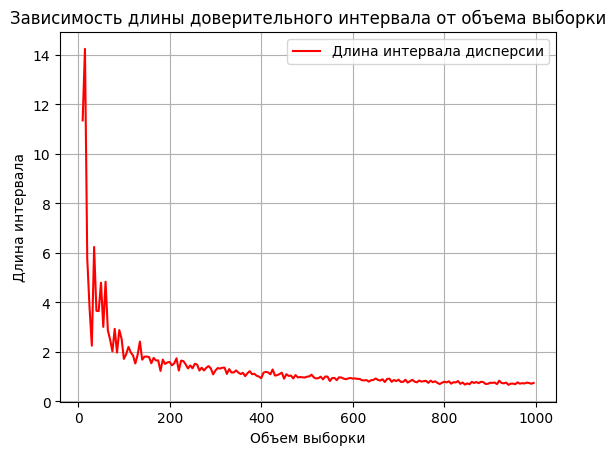

In [49]:
x_v_list_2 = []

for m in m_list:
    sample_item = np.random.normal(a, sigma, m)

    # Вычисляем интервальную оценку для дисперси
    vd = np.var(sample_item, ddof = 1)
    chi2_lower, chi2_upper = sts.chi2.interval(gamma, m-1)
    variance_interval = ((m-1) * vd / chi2_upper, (m-1) * vd / chi2_lower)
    
    x_v_list_2.append(variance_interval[1] - variance_interval[0])


plt.plot(m_list, x_v_list_2, label="Длина интервала дисперсии", color = "red")
plt.xlabel("Объем выборки")
plt.ylabel("Длина интервала")
plt.legend()
plt.grid()
plt.title("Зависимость длины доверительного интервала от объема выборки")
plt.show()

4. Смоделировать M выборок из n значений нормально распределенной случайной 
величины X с параметрами (a, sigma^2
). По каждой из M выборок с надежностью gamma найти 
интервальную оценку (доверительный интервал) для математического ожидания 
случайной величины X, предполагая, что дисперсия случайной величины X неизвестна. 

In [81]:
count = 0.0
for i in range(0, M):
    sample_item = np.random.normal(a, sigma, n)
    mean = st.mean(sample_item)

    S = np.sqrt(np.var(sample_item, ddof = 1))

    interval = sts.t.interval(gamma, n-1, mean, S/math.sqrt(n))

    if interval[0]<a and interval[1]>a:
        count +=1

gamma_0 = count/(M)

print(f"\nТочечная оценка надёжности = {gamma_0}")


Точечная оценка надёжности = 0.95


5. Смоделировать M выборок из n значений нормально распределенной случайной 
величины X с параметрами (a, sigma^2
). 

5.1. По каждой из M выборок найти наблюдаемое значение случайной величины Z
(описание случайной величины Z приведено в Вашем варианте)

In [3]:
z_list = []
for i in range(0, M):
    sample_i = np.random.normal(a, sigma, n)
    S = np.sqrt(np.var(sample_i, ddof = 1))
    mean = st.mean(sample_i)

    z_list.append((mean - a)*np.sqrt(n)/S)

z_list

[1.1202831271958835,
 0.7972785566487886,
 0.7342679028787672,
 -1.0633975747613746,
 0.9907209106221783,
 -0.37123566783031753,
 -2.176199644992207,
 -1.6141728344059998,
 0.8795572609552832,
 0.2557038967312178,
 -0.9460093678166711,
 0.1894441392310684,
 0.16014689414309682,
 -0.9028051999873392,
 0.22248216212771685,
 -0.3649844635796693,
 -1.1442022365978022,
 0.4677949065980921,
 1.8241323167280896,
 -1.096636054890524,
 -0.6557522920577935,
 1.475359918007266,
 0.13488710940404194,
 -0.005578165608732466,
 -0.6134075581308018,
 -0.09918911560158188,
 0.3238859672466131,
 0.5797854995707189,
 0.7245315670064519,
 -0.12578037286789467,
 -0.31326004700915633,
 0.8598163015302754,
 1.293872254378291,
 -1.5881404517401587,
 -0.8447851256014239,
 -1.4165770951107999,
 -1.033531647279065,
 -0.4637077179266149,
 -1.9581776664751749,
 2.146129055812668,
 -0.5640060925086362,
 -0.8197449286190721,
 -0.3793329977323732,
 -1.2725581235988757,
 0.5217884283329186,
 0.3448223457552615,
 -2.58

5.2. Каков закон распределения случайной величины Z?

Ответ: Стьюдент

5.3. По выборке из M значений случайной величины Z найти выборочные числовые 
характеристики ее распределения.

In [14]:
print("Среднее значение = ", np.mean(z_list))
print("Дисперсия = ", np.var(z_list, ddof = 1))
print("Стандартное отклонение = ", np.std(z_list))
print("Медиана = ",np.median(z_list))
print("Минимальное значение = ", np.min(z_list))
print("Максимальное значение = ", np.max(z_list))

Среднее значение =  -0.04139281244892645
Дисперсия =  1.1552861726262014
Стандартное отклонение =  1.0745437855084095
Медиана =  -0.03727441646902109
Минимальное значение =  -5.004555374864659
Максимальное значение =  4.7554653322432605


5.4. Построить гистограмму относительных частот и теоретическую кривую 
распределения случайной величины Z, а также ящичковую диаграмму.

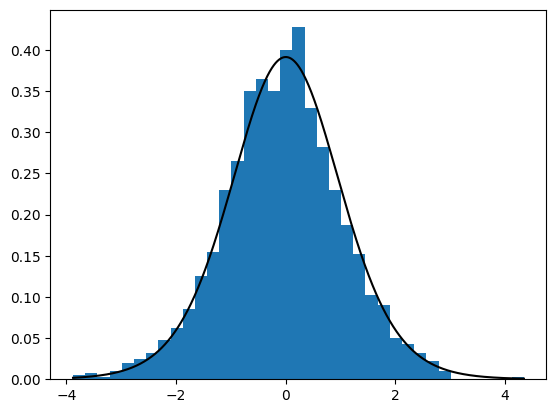

In [4]:
plt.hist(z_list, density=True, bins="auto")
a = st.mean(z_list)
sigma = st.stdev(z_list)
x = np.linspace(np.min(z_list), np.max(z_list), M)
y = sts.t.pdf(x, n - 1)
plt.plot(x, y, color = "black")

Первый квартиль: -0.6852589410098096
Второй квартиль: 0.016082554705536104
Третий квартиль: 0.775659171423324
Межквартильный диапозон: 1.4609181124331334
Нижний предел: -2.8766361096595094
Верхний предел: 2.967036340073024
Число выбросов: 19
Выбросы: 
-3.3617712894317697	
3.755256666603803	
-3.8663249069044148	
3.178530579874388	
2.9695845553879114	
-2.9166267608465706	
3.2836375446127466	
3.245817963572883	
-2.9439373504386883	
3.237251612117404	
-3.146177210749263	
3.292718272702516	
3.3714173498174596	
3.4342570640854717	
-4.241188671298119	
3.1832240174865354	
-3.007106896113776	
3.3577932398243258	
3.537541461220582	


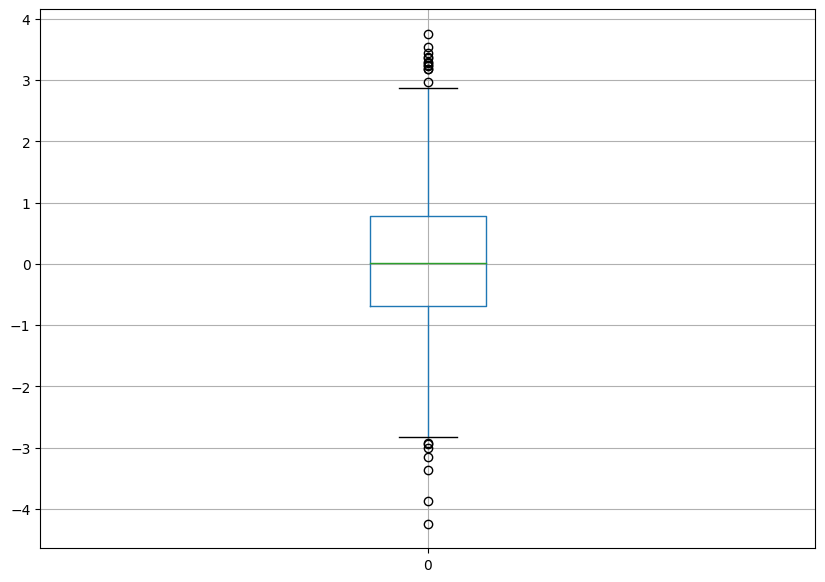

In [86]:
d = pd.DataFrame(data=z_list)
d.boxplot(figsize = (10, 7))


q_1 = np.percentile(z_list, 25)
print(f'Первый квартиль: {q_1}')
q_2 = np.percentile(z_list, 50)
print(f'Второй квартиль: {q_2}')
q_3 = np.percentile(z_list, 75)
print(f'Третий квартиль: {q_3}')
iqr = q_3 - q_1
print(f'Межквартильный диапозон: {iqr}')
lower_bound = q_1 - 1.5 * iqr
print(f'Нижний предел: {lower_bound}')
upper_bound = q_3 + 1.5 * iqr
print(f'Верхний предел: {upper_bound}')

outliers = []
for i in z_list:
    if (i < lower_bound) or (i > upper_bound):
        outliers.append(i)
number_outliers = len(outliers)

print(f'Число выбросов: {number_outliers}')
print('Выбросы: ')
for i in range(len(outliers)):
    print(f'{outliers[i]}\t')

Часть II

1. Смоделировать M выборок из n значений нормально распределенной случайной 
величины X с параметрами (a, sigma^2). По каждой из M выборок с надежностью gamma найти 
интервальную оценку (доверительный интервал) для дисперсии случайной величины X.

По результатам моделирования найти точечную оценку gamma* надежности gamma.



In [87]:
count = 0.0
for j in range(0,M):
    sample_i = np.random.normal(a, sigma, n)
    
    S = np.var(sample_i, ddof=1)
    chi2_lower, chi2_upper = sts.chi2.interval(gamma, n-1)


    right_bound = ((n-1) * S) / chi2_upper
    left_bound = ((n-1) * S) / chi2_lower
    
    if right_bound<sigma**2 and left_bound>sigma**2:
        count +=1

GAMMA = count/M
print(GAMMA)

0.9461111111111111


2. Повторив пункт 1. K раз, получите массив из K значений оценки gamma*. Найдите 
выборочные числовые характеристики оценки gamma*, постройте гистограмму относительных 
частот и бокс-плот. Каким может быть закон распределения оценки gamma* ? Чему равны 
математическое ожидание и дисперсия оценки gamma* 

In [5]:
K_list = []
for i in range(0, K):
    count = 0.0
    for j in range(0,M):
        sample_i = np.random.normal(a, sigma, n)

        S = np.var(sample_i, ddof=1)

        chi2_lower, chi2_upper = sts.chi2.interval(gamma, n-1)

        right_bound = ((n-1) * S) / chi2_upper
        left_bound = ((n-1) * S) / chi2_lower

        if left_bound<sigma**2 and  right_bound>sigma**2:
            count +=1

    K_list.append(count/M)

3. Смоделировать M выборок из n значений случайной величины W, закон распределения 
которой указан в Вашем варианте. По каждой из M выборок с надежностью  найти 
интервальную оценку (доверительный интервал) для дисперсии случайной величины W. 
По результатам моделирования найти точечную оценку * надежности .

4. Повторив пункт 3. K раз, получите массив из K значений оценки *. Найдите 
выборочные числовые характеристики оценки *, постройте гистограмму относительных 
частот и бокс-плот. Каким может быть закон распределения оценки * ?